In [2]:
import pandas as pd
import numpy as np

print("Student Performance Prediction System")
print("Module: Student Risk Detection")
print("Libraries imported successfully!")

Student Performance Prediction System
Module: Student Risk Detection
Libraries imported successfully!


In [4]:
students = {
    "Student_ID": [
        "ST201", "ST202", "ST203", "ST204", "ST205",
        "ST206", "ST207", "ST208", "ST209", "ST210"
    ],
    "Study_Hours": [1, 6, 2, 8, 3, 7, 1, 5, 9, 4],
    "Attendance": [45, 90, 55, 96, 62, 85, 40, 78, 98, 68],
    "Average_Marks": [32, 86, 45, 94, 52, 80, 28, 72, 97, 60],
    "Assignments_Completed": [2, 10, 4, 10, 5, 9, 1, 8, 10, 6]
}

df = pd.DataFrame(students)

print("STUDENT RISK MONITORING DATA")
print("=" * 65)
print(df.to_string(index=False))

print("\nTotal Students:", len(df))
print("Data Columns:", list(df.columns))

STUDENT RISK MONITORING DATA
Student_ID  Study_Hours  Attendance  Average_Marks  Assignments_Completed
     ST201            1          45             32                      2
     ST202            6          90             86                     10
     ST203            2          55             45                      4
     ST204            8          96             94                     10
     ST205            3          62             52                      5
     ST206            7          85             80                      9
     ST207            1          40             28                      1
     ST208            5          78             72                      8
     ST209            9          98             97                     10
     ST210            4          68             60                      6

Total Students: 10
Data Columns: ['Student_ID', 'Study_Hours', 'Attendance', 'Average_Marks', 'Assignments_Completed']


In [6]:
df["Attendance_Risk"] = (100 - df["Attendance"]) * 0.35

df["Marks_Risk"] = (100 - df["Average_Marks"]) * 0.35

df["Study_Risk"] = (
    (df["Study_Hours"].clip(upper=6) - df["Study_Hours"]).abs()
    / 6 * 100
) * 0.15

df["Assignment_Risk"] = (
    (10 - df["Assignments_Completed"]) / 10 * 100
) * 0.15

df["Risk_Score"] = (
    df["Attendance_Risk"]
    + df["Marks_Risk"]
    + df["Study_Risk"]
    + df["Assignment_Risk"]
).clip(0, 100).round(2)

print("STUDENT RISK SCORES")
print("=" * 55)

print(
    df[["Student_ID", "Risk_Score"]]
    .sort_values("Risk_Score", ascending=False)
    .to_string(index=False)
)

STUDENT RISK SCORES
Student_ID  Risk_Score
     ST207       59.70
     ST201       55.05
     ST203       44.00
     ST205       37.60
     ST210       31.20
     ST208       20.50
     ST206       16.25
     ST209        9.25
     ST204        8.50
     ST202        8.40


In [9]:
df["Study_Risk"] = (
    (6 - df["Study_Hours"]).clip(lower=0) / 6 * 100
) * 0.15

In [11]:
def classify_risk(score):
    if score >= 60:
        return "High Risk"
    elif score >= 35:
        return "Medium Risk"
    else:
        return "Low Risk"


df["Risk_Level"] = df["Risk_Score"].apply(classify_risk)

print("STUDENT RISK CLASSIFICATION")
print("=" * 65)

print(
    df[["Student_ID", "Risk_Score", "Risk_Level"]]
    .sort_values("Risk_Score", ascending=False)
    .to_string(index=False)
)

STUDENT RISK CLASSIFICATION
Student_ID  Risk_Score  Risk_Level
     ST207       59.70 Medium Risk
     ST201       55.05 Medium Risk
     ST203       44.00 Medium Risk
     ST205       37.60 Medium Risk
     ST210       31.20    Low Risk
     ST208       20.50    Low Risk
     ST206       16.25    Low Risk
     ST209        9.25    Low Risk
     ST204        8.50    Low Risk
     ST202        8.40    Low Risk


In [13]:
support_list = df[df["Risk_Level"] == "High Risk"].copy()

print("STUDENTS FLAGGED FOR ADDITIONAL SUPPORT")
print("=" * 75)

if support_list.empty:
    print("No students flagged in the High Risk category.")
else:
    print(
        support_list[
            [
                "Student_ID",
                "Attendance",
                "Average_Marks",
                "Study_Hours",
                "Risk_Score"
            ]
        ].to_string(index=False)
    )

print("\nStudents flagged:", len(support_list))

STUDENTS FLAGGED FOR ADDITIONAL SUPPORT
No students flagged in the High Risk category.

Students flagged: 0


In [15]:
def suggest_support(student):
    actions = []

    if student["Attendance"] < 75:
        actions.append("Discuss attendance barriers")

    if student["Average_Marks"] < 60:
        actions.append("Offer subject revision support")

    if student["Study_Hours"] < 3:
        actions.append("Create a manageable study routine")

    if student["Assignments_Completed"] < 7:
        actions.append("Plan assignment completion")

    if not actions:
        actions.append("Review progress and maintain good habits")

    return " | ".join(actions)


df["Support_Actions"] = df.apply(suggest_support, axis=1)

print("STUDENT SUPPORT ACTION PLAN")
print("=" * 95)

print(
    df[
        ["Student_ID", "Risk_Level", "Support_Actions"]
    ].to_string(index=False)
)

STUDENT SUPPORT ACTION PLAN
Student_ID  Risk_Level                                                                                                               Support_Actions
     ST201 Medium Risk Discuss attendance barriers | Offer subject revision support | Create a manageable study routine | Plan assignment completion
     ST202    Low Risk                                                                                      Review progress and maintain good habits
     ST203 Medium Risk Discuss attendance barriers | Offer subject revision support | Create a manageable study routine | Plan assignment completion
     ST204    Low Risk                                                                                      Review progress and maintain good habits
     ST205 Medium Risk                                     Discuss attendance barriers | Offer subject revision support | Plan assignment completion
     ST206    Low Risk                                                        

In [17]:
risk_summary = df["Risk_Level"].value_counts()

risk_order = ["Low Risk", "Medium Risk", "High Risk"]
risk_summary = risk_summary.reindex(risk_order, fill_value=0)

print("=" * 50)
print("STUDENT RISK DISTRIBUTION REPORT")
print("=" * 50)

for level, count in risk_summary.items():
    percentage = (count / len(df)) * 100
    print(f"{level}: {count} students ({percentage:.1f}%)")

print("-" * 50)
print("Total Students Analyzed:", len(df))
print("Average Risk Score:", round(df["Risk_Score"].mean(), 2))
print("=" * 50)

STUDENT RISK DISTRIBUTION REPORT
Low Risk: 6 students (60.0%)
Medium Risk: 4 students (40.0%)
High Risk: 0 students (0.0%)
--------------------------------------------------
Total Students Analyzed: 10
Average Risk Score: 29.04


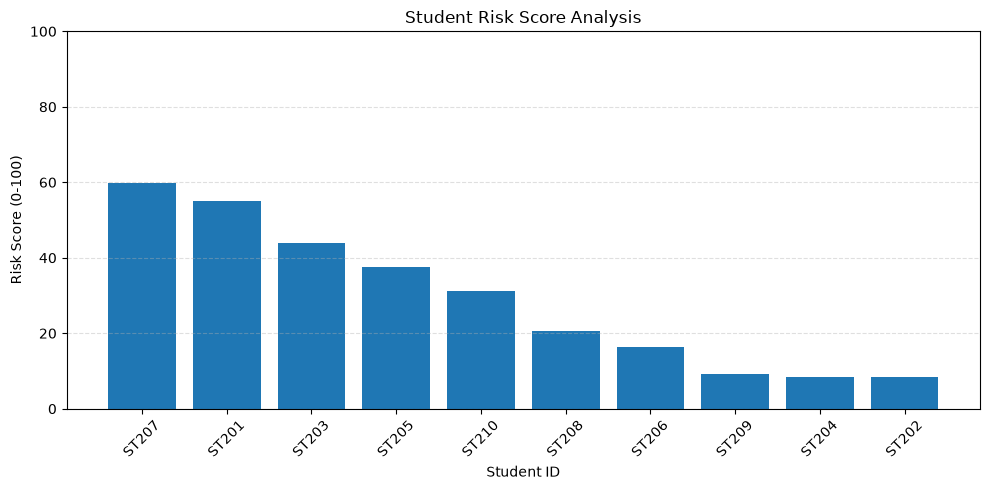

In [21]:
import matplotlib.pyplot as plt

risk_chart = df.sort_values(
    "Risk_Score",
    ascending=False
)

plt.figure(figsize=(10, 5))

plt.bar(
    risk_chart["Student_ID"],
    risk_chart["Risk_Score"]
)

plt.title("Student Risk Score Analysis")
plt.xlabel("Student ID")
plt.ylabel("Risk Score (0-100)")
plt.ylim(0, 100)

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [23]:
import os
import pandas as pd

# Create the Data folder if it does not exist
os.makedirs("Data", exist_ok=True)

report_columns = [
    "Student_ID",
    "Attendance",
    "Average_Marks",
    "Study_Hours",
    "Assignments_Completed",
    "Risk_Score",
    "Risk_Level",
    "Support_Actions"
]

risk_report = df[report_columns].copy()

file_path = os.path.join(
    "Data",
    "day15_student_risk_report.csv"
)

risk_report.to_csv(file_path, index=False)

print("=" * 55)
print("STUDENT RISK REPORT EXPORTED SUCCESSFULLY!")
print("=" * 55)

print("File Location:", os.path.abspath(file_path))
print("Total Records:", len(risk_report))
print("Total Columns:", len(risk_report.columns))

print("\nReport Preview:")
print(risk_report.head().to_string(index=False))

STUDENT RISK REPORT EXPORTED SUCCESSFULLY!
File Location: c:\Internship_project\Data\Data\day15_student_risk_report.csv
Total Records: 10
Total Columns: 8

Report Preview:
Student_ID  Attendance  Average_Marks  Study_Hours  Assignments_Completed  Risk_Score  Risk_Level                                                                                                               Support_Actions
     ST201          45             32            1                      2       55.05 Medium Risk Discuss attendance barriers | Offer subject revision support | Create a manageable study routine | Plan assignment completion
     ST202          90             86            6                     10        8.40    Low Risk                                                                                      Review progress and maintain good habits
     ST203          55             45            2                      4       44.00 Medium Risk Discuss attendance barriers | Offer subject revision suppo

In [24]:
print("=" * 65)
print("STUDENT PERFORMANCE PREDICTION SYSTEM")
print("DAY 15: STUDENT RISK DETECTION SYSTEM")
print("=" * 65)

print("\nPROJECT SUMMARY")
print("-" * 65)

print("Total Students Analyzed:", len(df))
print("Average Risk Score:", round(df["Risk_Score"].mean(), 2))

print("\nRISK CATEGORY SUMMARY")
print("-" * 65)

for level in ["Low Risk", "Medium Risk", "High Risk"]:
    count = (df["Risk_Level"] == level).sum()
    print(f"{level}: {count} students")

print("\nFEATURES COMPLETED")
print("-" * 65)

features = [
    "Student dataset creation",
    "Weighted risk score calculation",
    "Risk category classification",
    "Additional support identification",
    "Personalized support action suggestions",
    "Risk distribution summary",
    "Risk score visualization",
    "CSV report export"
]

for number, feature in enumerate(features, start=1):
    print(f"{number}. {feature}")

print("\nOUTPUT FILE")
print("-" * 65)
print("day15_student_risk_report.csv")

print("\nDay 15 implementation completed!")
print("=" * 65)

STUDENT PERFORMANCE PREDICTION SYSTEM
DAY 15: STUDENT RISK DETECTION SYSTEM

PROJECT SUMMARY
-----------------------------------------------------------------
Total Students Analyzed: 10
Average Risk Score: 29.04

RISK CATEGORY SUMMARY
-----------------------------------------------------------------
Low Risk: 6 students
Medium Risk: 4 students
High Risk: 0 students

FEATURES COMPLETED
-----------------------------------------------------------------
1. Student dataset creation
2. Weighted risk score calculation
3. Risk category classification
4. Additional support identification
5. Personalized support action suggestions
6. Risk distribution summary
7. Risk score visualization
8. CSV report export

OUTPUT FILE
-----------------------------------------------------------------
day15_student_risk_report.csv

Day 15 implementation completed!
